In [3]:
import kagglehub
path = kagglehub.dataset_download("lsind18/tarot-json")

100%|██████████| 7.41M/7.41M [00:00<00:00, 157MB/s]

Extracting files...


In [19]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/lsind18/tarot-json/versions/3
/root/.cache/kagglehub/datasets/lsind18/tarot-json/versions/3/cards


In [20]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/lsind18/tarot-json/versions/3
/root/.cache/kagglehub/datasets/lsind18/tarot-json/versions/3/cards


In [4]:
import pandas as pd
import os

# The dataset was downloaded to the `path` variable earlier.
# Construct the correct path to the JSON file within the downloaded dataset.
df = pd.read_json(os.path.join(path, "tarot-images.json"))

print(df.head())

                                         description  \
0  tarot cards and basic information about them, ...   
1  tarot cards and basic information about them, ...   
2  tarot cards and basic information about them, ...   
3  tarot cards and basic information about them, ...   
4  tarot cards and basic information about them, ...   

                                               cards  
0  {'name': 'The Fool', 'number': '0', 'arcana': ...  
1  {'name': 'The Magician', 'number': '1', 'arcan...  
2  {'name': 'The High Priestess', 'number': '2', ...  
3  {'name': 'The Empress', 'number': '3', 'arcana...  
4  {'name': 'The Emperor', 'number': '4', 'arcana...  


In [13]:
df_cards = pd.json_normalize(df['cards'])
df_cards.head(2)

,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...",NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...","[Taking appropriate action, Receiving guidance...","[Inflating your own ego, Abusing talents, Mani...",NaN,NaN


In [ ]:
print(df.shape)

(78, 2)


In [ ]:
df_cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   Archetype           22 non-null     object
 8   Hebrew Alphabet     22 non-null     object
 9   Numerology          62 non-null     object
 10  Elemental           38 non-null     object
 11  Mythical/Spiritual  22 non-null     object
 12  Questions to Ask    78 non-null     object
 13  meanings.light      78 non-null     object
 14  meanings.shadow     78 non-null     object
 15  Astrology           40 non-null     object
 16  Affirmation         56 non-n

In [6]:
df_cards['number'] = pd.to_numeric(df_cards['number'])

print("DataFrame Info after converting 'number' to numeric:")
df_cards.info()

DataFrame Info after converting 'number' to numeric:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     int64 
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   Archetype           22 non-null     object
 8   Hebrew Alphabet     22 non-null     object
 9   Numerology          62 non-null     object
 10  Elemental           38 non-null     object
 11  Mythical/Spiritual  22 non-null     object
 12  Questions to Ask    78 non-null     object
 13  meanings.light      78 non-null     object
 14  meanings.shadow     78 non-null     object
 15  Astrology           40 

In [8]:
print(df_cards.isnull().sum())

name                   0
number                 0
arcana                 0
suit                   0
img                    0
fortune_telling        0
keywords               0
Archetype             56
Hebrew Alphabet       56
Numerology            16
Elemental             40
Mythical/Spiritual    56
Questions to Ask       0
meanings.light         0
meanings.shadow        0
Astrology             38
Affirmation           22
dtype: int64


In [9]:
df_cards['Numerology'] = df_cards['Numerology'].fillna('Unknown')
print(df_cards['Numerology'].isnull().sum())

0


In [10]:
df_cards['Astrology'] = df_cards['Astrology'].fillna('Unknown')
print(df_cards['Astrology'].isnull().sum())

0


In [11]:
print("Unique values and counts for 'arcana':")
display(df_cards['arcana'].value_counts())

print("\nUnique values and counts for 'suit':")
display(df_cards['suit'].value_counts())

Unique values and counts for 'arcana':


,count
arcana,
Minor Arcana,56
Major Arcana,22



Unique values and counts for 'suit':


,count
suit,
Trump,22
Cups,14
Swords,14
Wands,14
Pentacles,14


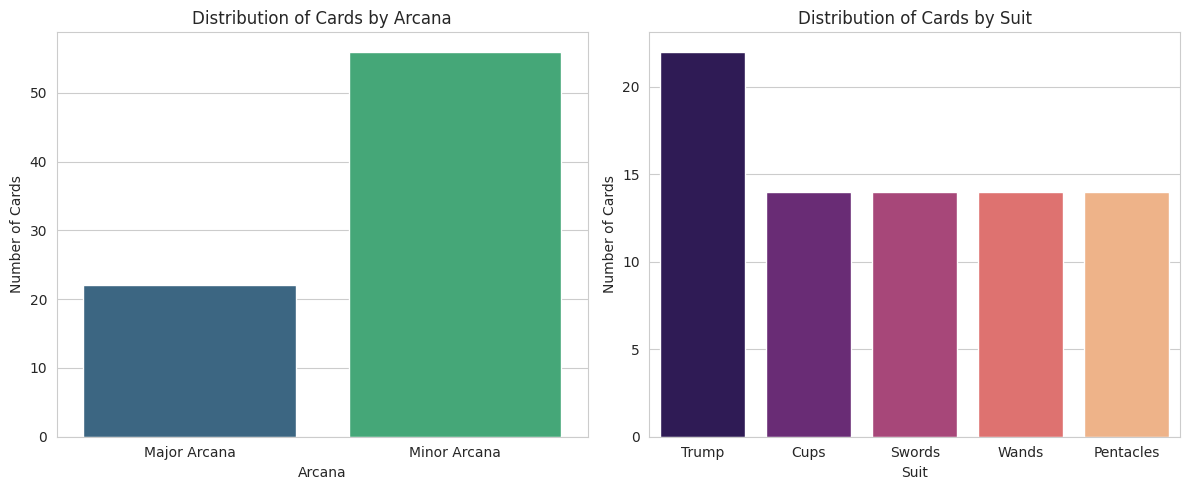

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

# Plot for 'arcana'
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x='arcana', data=df_cards, palette='viridis', hue='arcana', legend=False)
plt.title('Distribution of Cards by Arcana')
plt.xlabel('Arcana')
plt.ylabel('Number of Cards')

# Plot for 'suit'
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.countplot(x='suit', data=df_cards, palette='magma', hue='suit', legend=False)
plt.title('Distribution of Cards by Suit')
plt.xlabel('Suit')
plt.ylabel('Number of Cards')

plt.tight_layout()
plt.show()

In [14]:
df = df_cards.drop(columns=[
    "Archetype",
    "Hebrew Alphabet",
    "Mythical/Spiritual"
])

In [15]:
df_cards.head(2)

,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...",NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...","[Taking appropriate action, Receiving guidance...","[Inflating your own ego, Abusing talents, Mani...",NaN,NaN


In [24]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select 3 random cards
three_cards = df_cards.sample(3).reset_index(drop=True)

print("Choose a card:")
print("1")
print("2")
print("3")

choice = int(input("Enter your choice (1, 2, or 3): "))

selected_card = three_cards.iloc[choice-1]

Choose a card:
1
2
3
Enter your choice (1, 2, or 3): 2


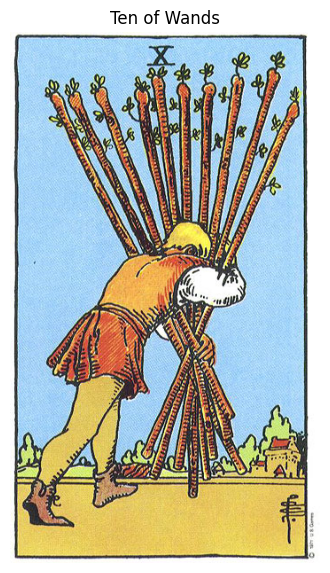


YOUR CARD
---------------------------
Name: Ten of Wands
Arcana: Minor Arcana
Suit: Wands

Keywords:
exhaustion, resistance, burden, oppression

Fortune Telling:
- You're worn out
- Back off, take a time out, and let someone else handle things for a while

Light Meaning:
- Holding your own in extreme circumstances
- Helping others carry their burdens
- Coming to the aid of the oppressed
- Knowing and being honest about your own limits
- Recognizing when you are not well-suited for a particular task

Shadow Meaning:
- Taking on more work than you know you can handle
- Refusing to say "No" when you're already overloaded
- Making a habit of working overtime
- Shielding others from facing the consequences of their own poor judgment
- Over-extending yourself on a regular basis

Question to Ask:
- How will you know when you reach the end of your rope?
- How easily do you say no to new projects and requests?
- What projects could you delegate...or eliminate?


In [26]:
image_folder = r"/root/.cache/kagglehub/datasets/lsind18/tarot-json/versions/3/cards"

img_path = os.path.join(image_folder, selected_card["img"])

img = Image.open(img_path)

plt.figure(figsize=(4,7))
plt.imshow(img)
plt.axis("off")
plt.title(selected_card["name"])
plt.show()


print("\nYOUR CARD")
print("---------------------------")
print("Name:", selected_card["name"])
print("Arcana:", selected_card["arcana"])
print("Suit:", selected_card["suit"])

print("\nKeywords:")
print(", ".join(selected_card["keywords"]))

print("\nFortune Telling:")
for text in selected_card["fortune_telling"]:
    print("-", text)

print("\nLight Meaning:")
for text in selected_card["meanings.light"]:
    print("-", text)

print("\nShadow Meaning:")
for text in selected_card["meanings.shadow"]:
    print("-", text)

print("\nQuestion to Ask:")
for text in selected_card["Questions to Ask"]:
    print("-", text)


YOUR CARD
---------------------------
Name: Page of Pentacles
Arcana: Minor Arcana
Suit: Pentacles

Keywords:
practicality, prosperity, learning, growth, adolescence

Fortune Telling:
- This card represents a young man or woman with an earthy, practical demeanor, likely born an Aries, Taurus, or Gemini, who playfully encourages you to take financial or sexual risks

Light Meaning:
- Learning the value of a dollar
- Starting a savings plan
- Taking the first steps toward getting out of debt
- Learning new physical tasks
- Discovering your sexuality
- Launching a diet, a weight-lifting program, or a health-related effort
- Learning by doing

Shadow Meaning:
- Trying to appear healthier or wealthier than you really are
- Spending money carelessly
- Living strictly for today, with no thought of tomorrow
- Possessing immature attitudes toward sex and sexuality
- Using wealth or beauty as an excuse for not having to learn and grow

Question to Ask:
- How can you get more financial or sexual